# **Pastikan sudah di download terlebih dahulu colabnya, atau di salin. Terimakasih :)**

# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [3]:
train = pd.read_csv('cardata.csv')
train.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


### Exploratory Data Analysis

In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [5]:
d = train.describe()
d

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


C:\Users\ASUS\AppData\Local\Temp\ipykernel_30616\4266552354.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Transmission', data=train, palette='RdBu_r')


<Axes: xlabel='Transmission', ylabel='count'>

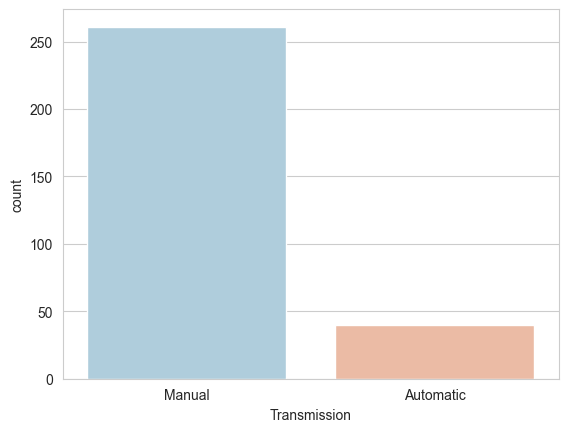

In [7]:
# Cek relative size dari survived dan not survived
sns.set_style('whitegrid')
sns.countplot(x='Transmission', data=train, palette='RdBu_r')

<Axes: xlabel='Transmission', ylabel='count'>

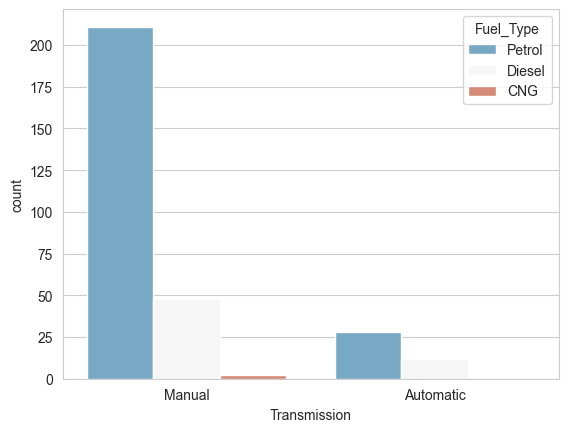

In [24]:
sns.set_style('whitegrid')
sns.countplot(x='Transmission', hue='Fuel_Type', data=train, palette='RdBu_r')

<Axes: xlabel='Transmission', ylabel='count'>

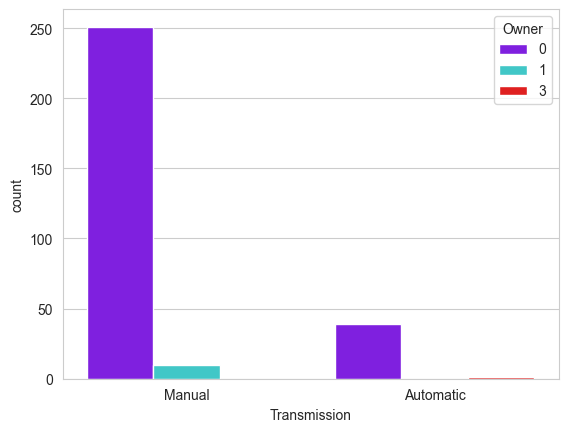

In [25]:
sns.set_style('whitegrid')
sns.countplot(x='Transmission', hue='Owner', data=train, palette='rainbow')

Text(0.5, 1.0, 'Distribusi Transmission berdasarkan Seller Type')

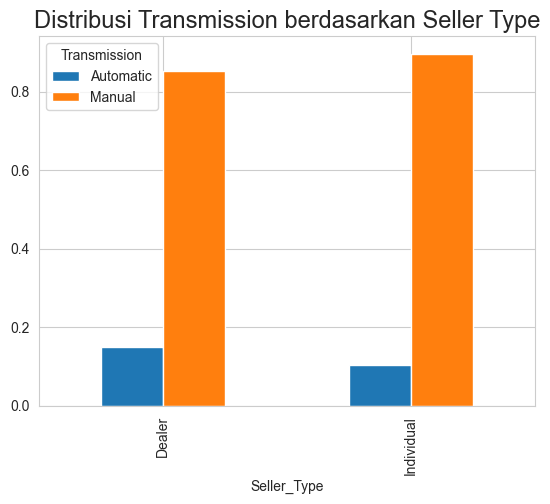

In [22]:
f_class_trans = train.groupby('Seller_Type')['Transmission'].value_counts(normalize=True).unstack()

f_class_trans.plot.bar()
plt.title("Distribusi Transmission berdasarkan Seller Type", fontsize=17)

<Axes: xlabel='Transmission', ylabel='Kms_Driven'>

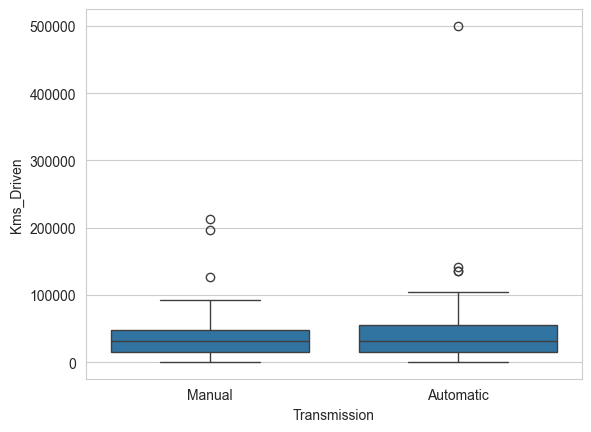

In [26]:
sns.set_style('whitegrid')
sns.boxplot(x='Transmission', y='Kms_Driven', data=train)

<Axes: title={'center': 'Histogram Jarak Tempuh Mobil (Kms Driven)'}, xlabel='Jarak Tempuh (Km)', ylabel='Jumlah Mobil'>

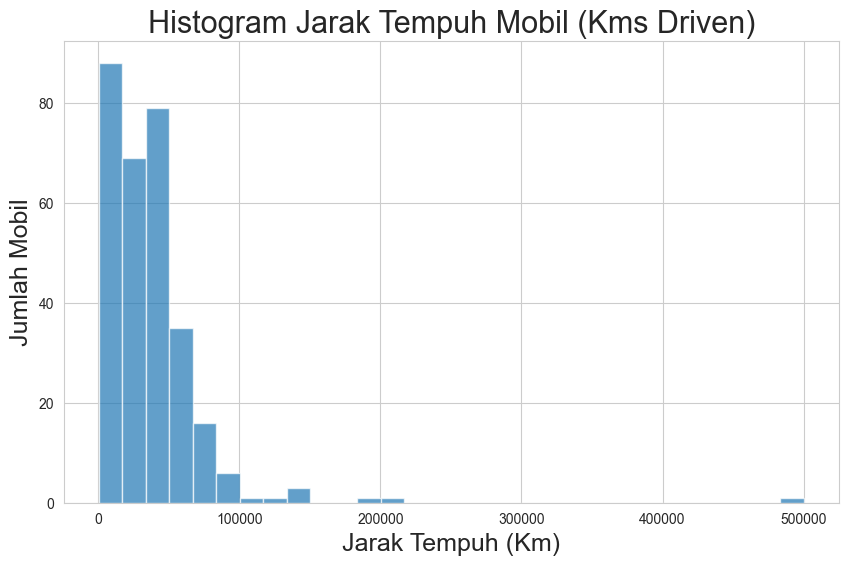

In [27]:
plt.figure(figsize=(10,6))

plt.xlabel("Jarak Tempuh (Km)", fontsize=18)
plt.ylabel("Jumlah Mobil", fontsize=18)
plt.title("Histogram Jarak Tempuh Mobil (Kms Driven)", fontsize=22)

train['Kms_Driven'].hist(bins=30, alpha=0.7)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_30616\3500353118.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Fuel_Type', y='Kms_Driven', data=train, palette='winter')


<Axes: xlabel='Jenis Bahan Bakar', ylabel='Jarak Tempuh (Km)'>

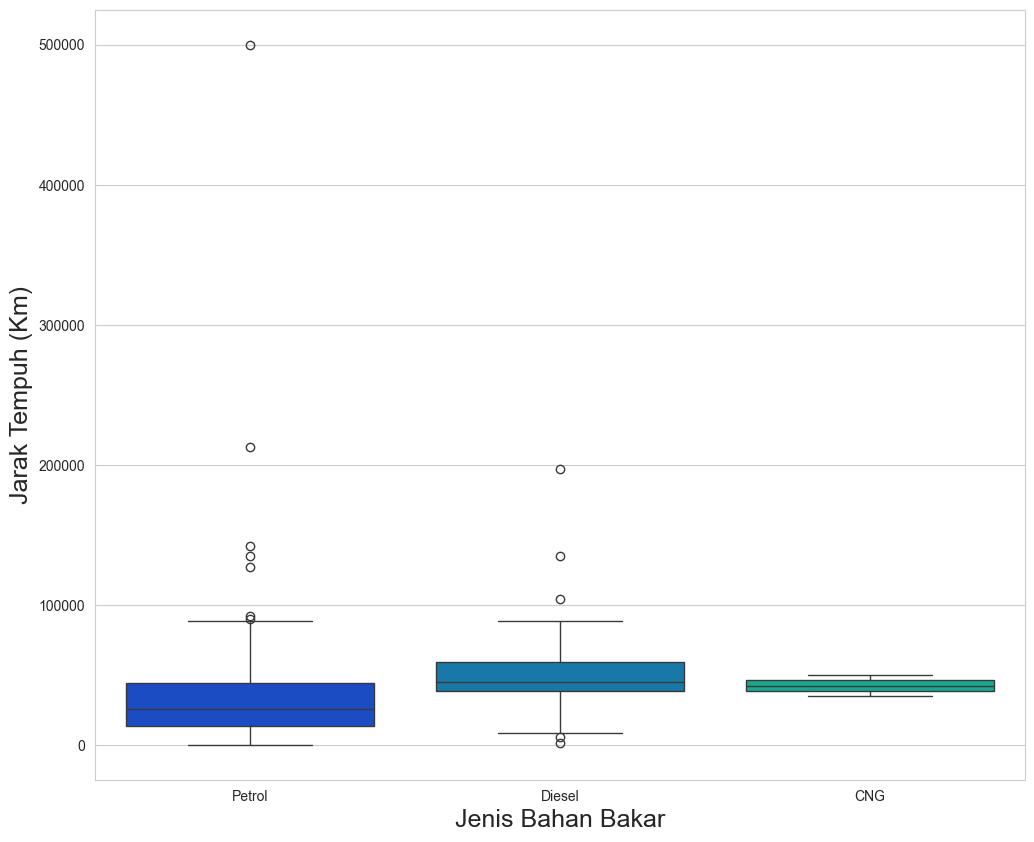

In [28]:
plt.figure(figsize=(12, 10))
plt.xlabel("Jenis Bahan Bakar", fontsize=18)
plt.ylabel("Jarak Tempuh (Km)", fontsize=18)
sns.boxplot(x='Fuel_Type', y='Kms_Driven', data=train, palette='winter')

Text(0.5, 0, 'Fuel Type')

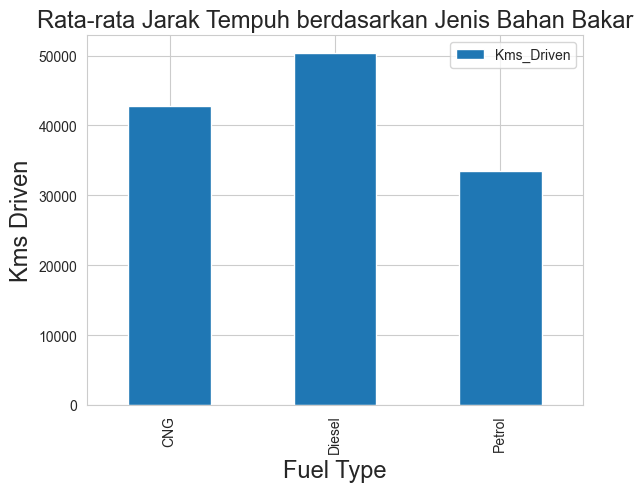

In [29]:
f_class_km = train.groupby('Fuel_Type')['Kms_Driven'].mean()
f_class_km = pd.DataFrame(f_class_km)

f_class_km.plot.bar(y='Kms_Driven')
plt.title("Rata-rata Jarak Tempuh berdasarkan Jenis Bahan Bakar", fontsize=17)
plt.ylabel("Kms Driven", fontsize=17)
plt.xlabel("Fuel Type", fontsize=17)

### Fitur Engineering

In [33]:
km_mean = train.groupby('Fuel_Type')['Kms_Driven'].mean().to_dict()

def impute_km(cols):
    Kms = cols['Kms_Driven']
    Fuel = cols['Fuel_Type']

    if pd.isnull(Kms):
        return km_mean[Fuel]
    else:
        return Kms

In [34]:
train['Kms_Driven'] = train[['Kms_Driven', 'Fuel_Type']].apply(impute_km, axis=1)

Text(0.5, 1.0, 'Rata-rata setiap fitur numerik')

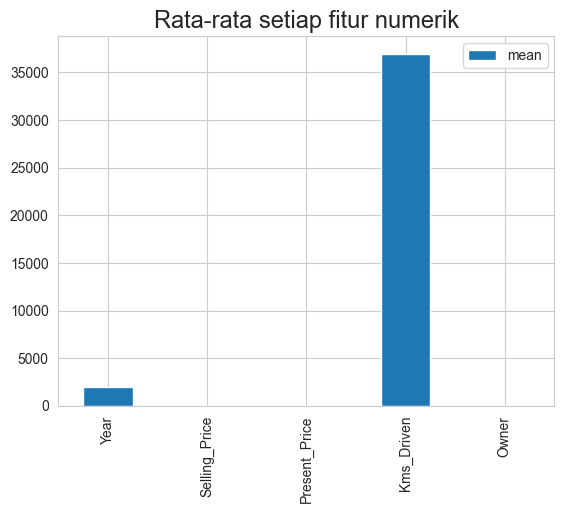

In [35]:
d = train.describe()
dT = d.T

dT.plot.bar(y='mean')
plt.title("Rata-rata setiap fitur numerik", fontsize=17)

In [36]:
train.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [38]:
if train.isnull().sum().sum() > 0:
    train = train.dropna()
else:
    print("Tidak ada missing value, tidak perlu drop data")

Tidak ada missing value, tidak perlu drop data


In [39]:
train.drop('Car_Name', axis=1, inplace=True)

train.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [40]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train['Fuel_Type'] = le.fit_transform(train['Fuel_Type'])
train['Seller_Type'] = le.fit_transform(train['Seller_Type'])
train['Transmission'] = le.fit_transform(train['Transmission'])

train.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,2,0,1,0
1,2013,4.75,9.54,43000,1,0,1,0
2,2017,7.25,9.85,6900,2,0,1,0
3,2011,2.85,4.15,5200,2,0,1,0
4,2014,4.60,6.87,42450,1,0,1,0


### Training

In [41]:
from sklearn.model_selection import train_test_split

X = train.drop('Transmission', axis=1)
y = train['Transmission']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

In [42]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (210, 7)
Test shape: (91, 7)


# **KNN**

In [45]:
from sklearn.neighbors import KNeighborsClassifier

clf1 = KNeighborsClassifier()
clf1.fit(X_train, y_train)

y_pred = clf1.predict(X_test)

In [47]:
y_pred = clf1.predict(X_test)

### Evaluation

In [48]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

Akurasi Model KNN: 0.81
Confusion Matrix:
[[ 1 16]
 [ 1 73]]
Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.06      0.11        17
           1       0.82      0.99      0.90        74

    accuracy                           0.81        91
   macro avg       0.66      0.52      0.50        91
weighted avg       0.76      0.81      0.75        91



# **Naive Bayes**

In [53]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

# Prediksi data uji
y_pred_nb = nb.predict(X_test)

### Evaluation

In [54]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f'Akurasi Naive Bayes: {accuracy_nb:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("Classification Report:")
print(classification_report(y_test, y_pred_nb))

Akurasi Naive Bayes: 0.87
Confusion Matrix:
[[ 7 10]
 [ 2 72]]
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.41      0.54        17
           1       0.88      0.97      0.92        74

    accuracy                           0.87        91
   macro avg       0.83      0.69      0.73        91
weighted avg       0.86      0.87      0.85        91



# **Decision Tree**

In [55]:
from sklearn.tree import DecisionTreeClassifier

# Inisialisasi dan latih model Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Prediksi data uji
y_pred_dt = dt.predict(X_test)

### Evaluation

In [56]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluasi model Decision Tree
accuracy = accuracy_score(y_test, y_pred_dt)
print(f'Akurasi Model Decision Tree: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

print(f"\nJumlah data test: {len(y_test)}")
print(f"Jumlah prediksi benar: {(y_test == y_pred_dt).sum()}")

Akurasi Model Decision Tree: 0.84
Confusion Matrix:
[[ 8  9]
 [ 6 68]]
Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.47      0.52        17
           1       0.88      0.92      0.90        74

    accuracy                           0.84        91
   macro avg       0.73      0.69      0.71        91
weighted avg       0.82      0.84      0.83        91


Jumlah data test: 91
Jumlah prediksi benar: 76


Krena yang lebih bagus adalah nilai evaluasinya model Naive Bayes, maka kita akan tes menggunakan data baru

In [57]:
# Data mobil baru
# Format:
# [Year, Selling_Price, Present_Price, Kms_Driven, Fuel_Type, Seller_Type, Owner]

new_data = np.array([[2015, 4.5, 6.8, 35000, 1, 0, 0]])

# Prediksi kelas (Transmission)
new_prediction = nb.predict(new_data)
print("Prediksi Transmission (0 = Manual, 1 = Automatic):", new_prediction[0])

# Prediksi probabilitas
proba = nb.predict_proba(new_data)
print("Probabilitas [Manual, Automatic]:", proba[0])

Prediksi Transmission (0 = Manual, 1 = Automatic): 1
Probabilitas [Manual, Automatic]: [0.00547636 0.99452364]


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


#---------------------------------------------------------------------------------------------------------------------------------


#---------------------------------------------------------------------------------------------------------------------------------

#---------------------------------------------------------------------------------------------------------------------------------

# **Contoh Penggunaan Parameter**

### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [58]:
from sklearn.neighbors import KNeighborsClassifier

clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred_knn = clf2.predict(X_test)

In [59]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_knn) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred_knn))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred_knn))

Akurasi Model KNN: 0.85
Confusion Matrix:
[[ 4 13]
 [ 1 73]]
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.24      0.36        17
           1       0.85      0.99      0.91        74

    accuracy                           0.85        91
   macro avg       0.82      0.61      0.64        91
weighted avg       0.84      0.85      0.81        91



### jika ingin mencoba semua parameter kita bisa menggunakan GridSearchCV

### Contoh penggunaan Model KNN dengan GridSearchCV

In [60]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# 1. Definisikan metrik evaluasi
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid KNN
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Model KNN
knn = KNeighborsClassifier()

# 4. GridSearchCV (optimasi berdasarkan F1-score)
grid_search = GridSearchCV(
    knn,
    param_grid,
    cv=5,
    scoring=scoring,
    refit='f1',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params',
                         'mean_test_accuracy',
                         'mean_test_precision',
                         'mean_test_recall',
                         'mean_test_f1']]

print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
0   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.890476   
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.890476   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.852381   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.847619   
8   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.890476   
2   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.890476   
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.838095   
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.838095   
11  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.857143   
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.857143   
4   {'metric': 'euclidean', 'n_neighbors

In [61]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_gridsearch_knn.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")

Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'


In [62]:
best_model = grid_search.best_estimator_

print("\n=== Parameter Terbaik KNN ===")
print(grid_search.best_params_)


=== Parameter Terbaik KNN ===
{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}


In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

y_pred = best_model.predict(X_test)

print("\n=== Evaluasi di Test Set (Best KNN Model) ===")

print(f"Akurasi:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set (Best KNN Model) ===
Akurasi:  0.81
Presisi:  0.66
Recall:   0.55
F1-Score: 0.54

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.12      0.19        17
           1       0.83      0.97      0.89        74

    accuracy                           0.81        91
   macro avg       0.66      0.55      0.54        91
weighted avg       0.77      0.81      0.76        91

Confusion Matrix:
[[ 2 15]
 [ 2 72]]


In [ ]:
import numpy as np

# Data mobil baru (urutan harus sama dengan X_train)
new_data_1 = np.array([[2015, 4.5, 6.8, 35000, 1, 0, 0]])

# Prediksi Transmission
prediction = best_model.predict(new_data_1)

print("Prediksi Transmission (0 = Manual, 1 = Automatic):", prediction[0])

Prediksi Transmission (0 = Manual, 1 = Automatic): 1


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
